In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
url = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/df_feng_done.csv'

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/df_feng_done.csv')

In [5]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

In [6]:
df.loc[df['Location'] == 'Monte Carlo', 'Location'] = 'Monte Carlo, Monaco'

## Extraemos ciudades

In [ ]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
import time

geolocator = Nominatim(user_agent="tennis_model", timeout=10) # Increased timeout to 10 seconds

ciudades = df['Location'].unique()

coords = {}
for ciudad in ciudades:
    try:
        location = geolocator.geocode(ciudad)
        if location:
            coords[ciudad] = (location.latitude, location.longitude)
            print(f"{ciudad}: {coords[ciudad]}")
        else:
            coords[ciudad] = (None, None) # Store None for coordinates if not found
            print(f"{ciudad}: NO ENCONTRADO")
    except (GeocoderTimedOut, GeocoderServiceError) as e:
        coords[ciudad] = (None, None)
        print(f"{ciudad}: ERROR - {e}")
    time.sleep(3) # Introduce a 1-second delay between requests

Doha: (25.3108807, 51.5081812)
Melbourne: (-37.8142454, 144.9631732)
Rotterdam: (51.9244424, 4.47775)
Rio de Janeiro: (-22.9110137, -43.2093727)
Acapulco: (16.8680495, -99.8940182)
Dubai : (25.0742823, 55.1885387)
Indian Wells: (33.7217965, -116.338303)
Miami: (25.7741566, -80.1935973)
Monte Carlo, Monaco: (43.7402961, 7.426559)
Barcelona: (41.3825802, 2.177073)
Munich: (48.1371079, 11.5753822)
Madrid: (40.416782, -3.703507)
Rome: (41.8933203, 12.4829321)
Paris: (48.8588897, 2.320041)
Halle: (51.4824354, 11.9712985)
London: (51.5074456, -0.1277653)
Hamburg: (53.5501721, 10.0013165)
Washington: (38.8950368, -77.0365427)
Montreal: (45.5031824, -73.5698065)
Cincinnati: (39.1014537, -84.5124602)
New York: (40.7127281, -74.0060152)
Beijing: (39.9057136, 116.3912972)
Tokyo: (35.6768601, 139.7638947)
Shanghai: (31.2312707, 121.4700152)
Vienna: (48.2083537, 16.3725042)
Basel: (47.5581077, 7.5878261)
Dallas: (32.7762719, -96.7968559)
Marseille: (43.2961743, 5.3699525)


In [ ]:
# pd.DataFrame(coords).T.rename(columns={0:'lat', 1:'lon'}).to_csv('coordsCiudades.csv')

Graficamos, esta todo OK

In [ ]:
!pip install folium
import folium

# Create a base map centered at an approximate average location
# For simplicity, let's use the first coordinate as a center for now
first_loc = list(coords_requests.keys())[0]
first_lat, first_lon = coords_requests[first_loc]
m = folium.Map(location=[first_lat, first_lon], zoom_start=2)

# Add markers for each location
for location, (lat, lon) in coords_requests.items():
    if lat is not None and lon is not None:
        folium.Marker(
            location=[lat, lon],
            popup=location,
            tooltip=location
        ).add_to(m)

# Display the map
m

Otra alternativa (no la use porque habia tenido problemas con Monte Carlo, Monaco):

In [ ]:
import requests

def get_coordinates(city):
    url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1"
    try:
      response = requests.get(url)
      data = response.json()

      if "results" in data:
          lat = data["results"][0]["latitude"]
          lon = data["results"][0]["longitude"]
          return lat, lon
    except:
      pass
    else:
        return None, None

In [ ]:
locations = df["Location"].unique()

coords_requests = {}

for loc in locations:
    lat, lon = get_coordinates(loc)
    coords_requests[loc] = (lat, lon)

In [ ]:
df_locations = pd.DataFrame(coords_requests).T.rename(columns={0:'lat', 1:'lon'})

## Ciudades + fechas

In [7]:
df_ciudades = pd.read_csv('https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/coordsCiudades.csv').rename(columns={'Unnamed: 0':'Ciudad'})

In [8]:
df = df.merge(df_ciudades, left_on = 'Location', right_on = 'Ciudad')

## Agregamos datos clima

In [9]:
! pip install openmeteo-requests
! pip install requests-cache retry-requests numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 718.6/718.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 63.3 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.6 MB/s eta 0:00:00


In [10]:
df_ciudades

,Ciudad,lat,lon
0,Doha,25.310881,51.508181
1,Melbourne,-37.814245,144.963173
2,Rotterdam,51.924442,4.477750
3,Rio de Janeiro,-22.911014,-43.209373
4,Acapulco,16.868050,-99.894018
5,Dubai,25.074282,55.188539
6,Indian Wells,33.721797,-116.338303
7,Miami,25.774157,-80.193597
8,"Monte Carlo, Monaco",43.740296,7.426559
9,Barcelona,41.382580,2.177073


In [11]:
for ciudad in df_ciudades['Ciudad']:
  latitud = df_ciudades[df_ciudades['Ciudad'] == ciudad]['lat'].values[0]
  longitud = df_ciudades[df_ciudades['Ciudad'] == ciudad]['lon'].values[0]
  fecha_min = df[df['Ciudad'] == ciudad]['Fecha'].min().strftime('%Y-%m-%d')
  fecha_max = df[df['Ciudad'] == ciudad]['Fecha'].max().strftime('%Y-%m-%d')
  print(ciudad, latitud, longitud, fecha_min, fecha_max)

Doha 25.3108807 51.5081812 2015-01-05 2025-02-22
Melbourne -37.8142454 144.9631732 2015-01-19 2025-01-26
Rotterdam 51.9244424 4.47775 2015-02-09 2025-02-09
Rio de Janeiro -22.9110137 -43.2093727 2015-02-16 2025-02-22
Acapulco 16.8680495 -99.8940182 2015-02-23 2025-03-02
Dubai  25.0742823 55.1885387 2015-02-23 2025-03-01
Indian Wells 33.7217965 -116.338303 2015-03-12 2025-03-16
Miami 25.7741566 -80.1935973 2015-03-25 2025-03-31
Monte Carlo, Monaco 43.7402961 7.426559 2015-04-12 2025-04-13
Barcelona 41.3825802 2.177073 2015-04-20 2025-04-20
Munich 48.1371079 11.5753822 2015-04-27 2025-04-20
Madrid 40.416782 -3.703507 2015-05-03 2025-05-03
Rome 41.8933203 12.4829321 2015-05-10 2025-05-18
Paris 48.8588897 2.320041 2015-05-24 2025-11-02
Halle 51.4824354 11.9712985 2015-06-15 2025-06-22
London 51.5074456 -0.1277653 2015-06-29 2025-07-13
Hamburg 53.5501721 10.0013165 2015-07-27 2025-05-24
Washington 38.8950368 -77.0365427 2015-08-03 2024-08-05
Montreal 45.5031824 -73.5698065 2015-08-10 2024-0

In [13]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry
import time

resultados = []

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"

for ciudad in df_ciudades['Ciudad']:
  latitud = df_ciudades[df_ciudades['Ciudad'] == ciudad]['lat'].values[0]
  longitud = df_ciudades[df_ciudades['Ciudad'] == ciudad]['lon'].values[0]
  fecha_min = df[df['Ciudad'] == ciudad]['Fecha'].min().strftime('%Y-%m-%d')
  fecha_max = df[df['Ciudad'] == ciudad]['Fecha'].max().strftime('%Y-%m-%d')

  params = {
    "latitude": latitud,
    "longitude": longitud,
    "start_date": fecha_min, # Formato: "2026-03-28"
    "end_date": fecha_max,
    "daily": ["temperature_2m_mean", "apparent_temperature_mean", "precipitation_sum", "rain_sum", "wind_speed_10m_max", "wind_gusts_10m_max", "wind_gusts_10m_mean", "wind_speed_10m_mean", "relative_humidity_2m_mean", "relative_humidity_2m_max", "relative_humidity_2m_min", "soil_temperature_0_to_100cm_mean", "soil_moisture_0_to_100cm_mean", "wind_gusts_10m_min", "wind_speed_10m_min"],
    "timezone": "auto",
  }
  responses = openmeteo.weather_api(url, params = params)

  # Process first location. Add a for-loop for multiple locations or weather models
  response = responses[0]
  # print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
  # print(f"Elevation: {response.Elevation()} m asl")
  # print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
  # print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

  # Process daily data. The order of variables needs to be the same as requested.
  daily = response.Daily()
  daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
  daily_apparent_temperature_mean = daily.Variables(1).ValuesAsNumpy()
  daily_precipitation_sum = daily.Variables(2).ValuesAsNumpy()
  daily_rain_sum = daily.Variables(3).ValuesAsNumpy()
  daily_wind_speed_10m_max = daily.Variables(4).ValuesAsNumpy()
  daily_wind_gusts_10m_max = daily.Variables(5).ValuesAsNumpy()
  daily_wind_gusts_10m_mean = daily.Variables(6).ValuesAsNumpy()
  daily_wind_speed_10m_mean = daily.Variables(7).ValuesAsNumpy()
  daily_relative_humidity_2m_mean = daily.Variables(8).ValuesAsNumpy()
  daily_relative_humidity_2m_max = daily.Variables(9).ValuesAsNumpy()
  daily_relative_humidity_2m_min = daily.Variables(10).ValuesAsNumpy()
  daily_soil_temperature_0_to_100cm_mean = daily.Variables(11).ValuesAsNumpy()
  daily_soil_moisture_0_to_100cm_mean = daily.Variables(12).ValuesAsNumpy()
  daily_wind_gusts_10m_min = daily.Variables(13).ValuesAsNumpy()
  daily_wind_speed_10m_min = daily.Variables(14).ValuesAsNumpy()

  daily_data = {"date": pd.date_range(
    start = pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
    end =  pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
    freq = pd.Timedelta(seconds = daily.Interval()),
    inclusive = "left"
  )}

  daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
  daily_data["apparent_temperature_mean"] = daily_apparent_temperature_mean
  daily_data["precipitation_sum"] = daily_precipitation_sum
  daily_data["rain_sum"] = daily_rain_sum
  daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
  daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
  daily_data["wind_gusts_10m_mean"] = daily_wind_gusts_10m_mean
  daily_data["wind_speed_10m_mean"] = daily_wind_speed_10m_mean
  daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
  daily_data["relative_humidity_2m_max"] = daily_relative_humidity_2m_max
  daily_data["relative_humidity_2m_min"] = daily_relative_humidity_2m_min
  daily_data["soil_temperature_0_to_100cm_mean"] = daily_soil_temperature_0_to_100cm_mean
  daily_data["soil_moisture_0_to_100cm_mean"] = daily_soil_moisture_0_to_100cm_mean
  daily_data["wind_gusts_10m_min"] = daily_wind_gusts_10m_min
  daily_data["wind_speed_10m_min"] = daily_wind_speed_10m_min

  daily_dataframe = pd.DataFrame(data = daily_data)
  daily_dataframe['Ciudad'] = ciudad
  print(f'La ciudad {ciudad} fue procesada con EXITO')
  resultados.append(daily_dataframe)
  # Descansa 10 segundos antes de volver a arrancar el for
  time.sleep(10)

La ciudad Doha fue procesada con EXITO
La ciudad Melbourne fue procesada con EXITO
La ciudad Rotterdam fue procesada con EXITO


OpenMeteoRequestsError: failed to request 'https://archive-api.open-meteo.com/v1/archive': {'reason': 'Minutely API request limit exceeded. Please try again in one minute.', 'error': True}

In [14]:
len(resultados)

3

In [ ]:
daily_dataframe.head()

,date,temperature_2m_mean,apparent_temperature_mean,precipitation_sum,rain_sum,wind_speed_10m_max,wind_gusts_10m_max,wind_gusts_10m_mean,wind_speed_10m_mean,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,soil_temperature_0_to_100cm_mean,soil_moisture_0_to_100cm_mean,wind_gusts_10m_min,wind_speed_10m_min,Ciudad
0,2015-04-12 00:00:00+00:00,13.769168,13.620551,0.0,0.0,7.421590,21.959999,12.690001,3.868165,81.383240,92.557625,70.286461,12.093541,0.351353,6.48,1.138420,"Monte Carlo, Monaco"
1,2015-04-13 00:00:00+00:00,15.417084,15.424397,0.0,0.0,9.746631,25.919998,15.060001,5.219631,78.493370,90.466553,61.197102,12.573876,0.348265,8.64,0.804985,"Monte Carlo, Monaco"
2,2015-04-14 00:00:00+00:00,15.512917,16.094946,0.0,0.0,8.217153,22.319998,13.995000,4.591398,84.318054,92.010254,70.247528,12.976043,0.345225,7.92,2.620839,"Monte Carlo, Monaco"
3,2015-04-15 00:00:00+00:00,15.269166,15.922130,0.0,0.0,8.225035,23.759998,14.549999,4.704120,87.833733,96.479202,78.014259,13.265606,0.342103,7.92,1.484318,"Monte Carlo, Monaco"
4,2015-04-16 00:00:00+00:00,14.985833,15.006808,0.8,0.8,6.618519,30.239998,18.614998,3.862360,81.258415,100.000000,64.604164,13.527894,0.339115,11.52,0.804985,"Monte Carlo, Monaco"


<Axes: ylabel='temperature_2m_mean'>

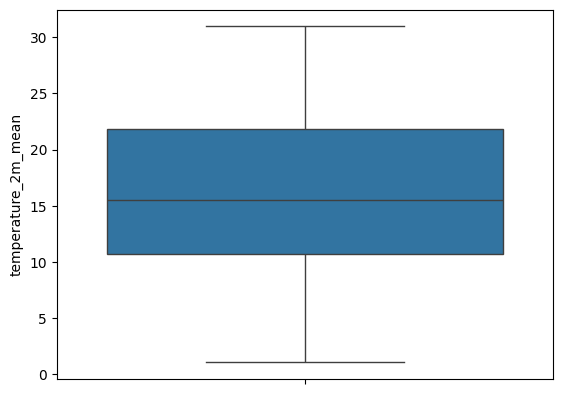

In [ ]:
sns.boxplot(data=daily_dataframe, y="temperature_2m_mean")

In [ ]:
def extraccion_clima(ciudad: str, latitud: float, longitud: float, fecha_comienzo: str, fecha_fin: str):
  import openmeteo_requests
  import pandas as pd
  import requests_cache
  from retry_requests import retry

  # Setup the Open-Meteo API client with cache and retry on error
  cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
  retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
  openmeteo = openmeteo_requests.Client(session = retry_session)

  # Make sure all required weather variables are listed here
  # The order of variables in hourly or daily is important to assign them correctly below
  url = "https://archive-api.open-meteo.com/v1/archive"
  params = {
    "latitude": latitud,
    "longitude": longitud,
    "start_date": fecha_comienzo, # Formato: "2026-03-28"
    "end_date": fecha_fin,
    "daily": ["temperature_2m_mean", "apparent_temperature_mean", "precipitation_sum", "rain_sum", "wind_speed_10m_max", "wind_gusts_10m_max", "wind_gusts_10m_mean", "wind_speed_10m_mean", "relative_humidity_2m_mean", "relative_humidity_2m_max", "relative_humidity_2m_min", "soil_temperature_0_to_100cm_mean", "soil_moisture_0_to_100cm_mean", "wind_gusts_10m_min", "wind_speed_10m_min"],
    "timezone": "Europe/London",
  }
  responses = openmeteo.weather_api(url, params = params)

  # Process first location. Add a for-loop for multiple locations or weather models
  response = responses[0]
  # print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
  # print(f"Elevation: {response.Elevation()} m asl")
  # print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
  # print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

  # Process daily data. The order of variables needs to be the same as requested.
  daily = response.Daily()
  daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
  daily_apparent_temperature_mean = daily.Variables(1).ValuesAsNumpy()
  daily_precipitation_sum = daily.Variables(2).ValuesAsNumpy()
  daily_rain_sum = daily.Variables(3).ValuesAsNumpy()
  daily_wind_speed_10m_max = daily.Variables(4).ValuesAsNumpy()
  daily_wind_gusts_10m_max = daily.Variables(5).ValuesAsNumpy()
  daily_wind_gusts_10m_mean = daily.Variables(6).ValuesAsNumpy()
  daily_wind_speed_10m_mean = daily.Variables(7).ValuesAsNumpy()
  daily_relative_humidity_2m_mean = daily.Variables(8).ValuesAsNumpy()
  daily_relative_humidity_2m_max = daily.Variables(9).ValuesAsNumpy()
  daily_relative_humidity_2m_min = daily.Variables(10).ValuesAsNumpy()
  daily_soil_temperature_0_to_100cm_mean = daily.Variables(11).ValuesAsNumpy()
  daily_soil_moisture_0_to_100cm_mean = daily.Variables(12).ValuesAsNumpy()
  daily_wind_gusts_10m_min = daily.Variables(13).ValuesAsNumpy()
  daily_wind_speed_10m_min = daily.Variables(14).ValuesAsNumpy()

  daily_data = {"date": pd.date_range(
    start = pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
    end =  pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
    freq = pd.Timedelta(seconds = daily.Interval()),
    inclusive = "left"
  )}

  daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
  daily_data["apparent_temperature_mean"] = daily_apparent_temperature_mean
  daily_data["precipitation_sum"] = daily_precipitation_sum
  daily_data["rain_sum"] = daily_rain_sum
  daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
  daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
  daily_data["wind_gusts_10m_mean"] = daily_wind_gusts_10m_mean
  daily_data["wind_speed_10m_mean"] = daily_wind_speed_10m_mean
  daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
  daily_data["relative_humidity_2m_max"] = daily_relative_humidity_2m_max
  daily_data["relative_humidity_2m_min"] = daily_relative_humidity_2m_min
  daily_data["soil_temperature_0_to_100cm_mean"] = daily_soil_temperature_0_to_100cm_mean
  daily_data["soil_moisture_0_to_100cm_mean"] = daily_soil_moisture_0_to_100cm_mean
  daily_data["wind_gusts_10m_min"] = daily_wind_gusts_10m_min
  daily_data["wind_speed_10m_min"] = daily_wind_speed_10m_min

  daily_dataframe = pd.DataFrame(data = daily_data)
  print(f'La ciudad {ciudad} fue procesada con EXITO')
  return daily_dataframe